# HW01: Intro to Text Data

In this assignment, we will explore how to load a text classification dataset (AG's news, originally posted [here](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html)), how we can preprocess the data and extract useful information from a real-world dataset. First, we have to download the data; we only download a subset of the data with four classes.

In [1]:
!curl -L -O https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 28.1M  100 28.1M    0     0  27.8M      0  0:00:01  0:00:01 --:--:-- 27.8M


## Inspect Data

In [6]:
import pandas as pd
df = pd.read_csv("train.csv", header=None)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       120000 non-null  int64 
 1   1       120000 non-null  object
 2   2       120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


,0,1,2
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Let's make the data more human readable by adding a header and replacing labels

In [7]:
df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 

In [4]:
df.head()

,label,title,lead
0,business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [8]:
# TODO implement a new column text which contains the lowercased title and lead (concatenated with space)
df["text"] = (df["title"] + " " + df["lead"]).str.lower()


In [9]:
# TODO print the number of documents for each label

print(df["label"].value_counts())


label
business    30000
sci/tech    30000
sport       30000
world       30000
Name: count, dtype: int64


## Document Length

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


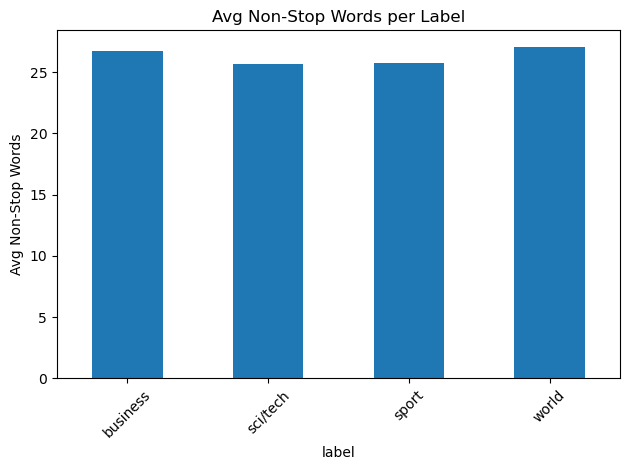

In [10]:
# TODO create a new column with the number of non-stop words in each text
# TODO plot the average number of non-stop words per label
# 
# 

import sys
# !{sys.executable} -m pip install nltk

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["num_non_stop_words"] = df["text"].apply(
    lambda text: sum(1 for w in text.split() if w not in stop_words)
)

df.groupby("label")["num_non_stop_words"].mean().plot(kind="bar", title="Avg Non-Stop Words per Label")
plt.ylabel("Avg Non-Stop Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

## Word Frequency 

Let's implement a keyword search (similar to the baker-bloom economic uncertainty) and compute how often some given keywords ("play", "tax", "blackberry", "israel") and numbers appear in the different classes in our data

In [11]:
import re
keywords = ["play", "tax", "blackberry", "israel"]
for keyword in keywords:
    x = r'\b' + keyword + r'\b'
    pattern = re.compile(x)
    def count_keyword_frequencies(text, p=pattern):
        num_occurrences = len(p.findall(text))
        return num_occurrences
    print(df["text"].apply(count_keyword_frequencies).sum())
    for label in df["label"].unique():
        count = df[df["label"] == label]["text"].apply(count_keyword_frequencies).sum()
        print("label:", label, ", keyword:", keyword, ", count:", count)
    print("*" * 100)


1802
label: business , keyword: play , count: 72
label: sci/tech , keyword: play , count: 220
label: sport , keyword: play , count: 1431
label: world , keyword: play , count: 79
****************************************************************************************************
1148
label: business , keyword: tax , count: 923
label: sci/tech , keyword: tax , count: 54
label: sport , keyword: tax , count: 13
label: world , keyword: tax , count: 158
****************************************************************************************************
228
label: business , keyword: blackberry , count: 44
label: sci/tech , keyword: blackberry , count: 184
label: sport , keyword: blackberry , count: 0
label: world , keyword: blackberry , count: 0
****************************************************************************************************
1485
label: business , keyword: israel , count: 17
label: sci/tech , keyword: israel , count: 36
label: sport , keyword: israel , count: 32
label: wo

As a last exercise, we re-use the fuzzy keyword search implemented above and plot the total number of occurrences of "tax" (and it's variations, e.g. taxation, taxes etc.) for each class in the dataset. Hint: have a look at the [pandas bar plot with group by](https://queirozf.com/entries/pandas-dataframe-plot-examples-with-matplotlib-pyplot)

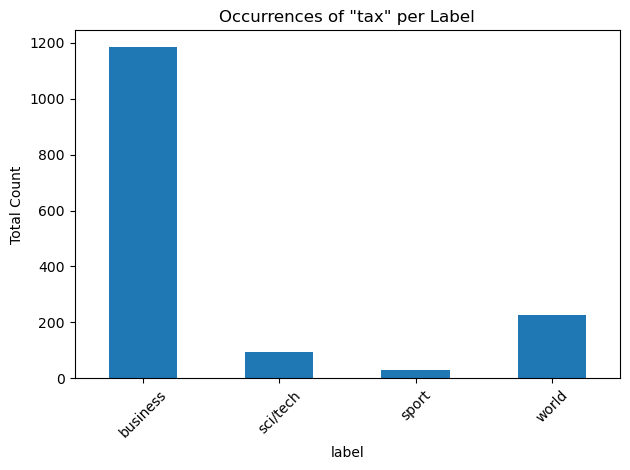

In [12]:
import matplotlib.pyplot as plt

keyword = "tax"
pattern = re.compile(r'\b' + keyword + r'\w*')

def count_keyword_frequencies(text):
    num_occurrences = len(pattern.findall(text))
    return num_occurrences

df["counts"] = df["text"].apply(count_keyword_frequencies)

df.groupby("label")["counts"].sum().plot(kind="bar", title=f'Occurrences of "{keyword}" per Label')
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
import os

os.system('jupyter nbconvert --to html homework_01.ipynb')

[NbConvertApp] Converting notebook homework_01.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 357780 bytes to homework_01.html


0

In [14]:
!open homework_01.html